### Step 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("indian_liver_patient.csv")

In [3]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 583
Columns: 11


In [5]:
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [7]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [8]:
df.describe(include="object")

,Gender
count,583
unique,2
top,Male
freq,441


In [9]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [10]:
df.duplicated().sum()

np.int64(13)

In [11]:
df["Dataset"].value_counts()

,count
Dataset,
1,416
2,167


In [14]:
df_clean = df.copy()

In [15]:
df_clean.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [16]:
df_clean = df_clean.apply(
    lambda x: x.str.strip() if x.dtype == "object" else x
)

In [17]:
num_cols = df_clean.select_dtypes(include=np.number).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [18]:
cat_cols = df_clean.select_dtypes(include="object").columns

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [19]:
df_clean.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,0


### Step 2 – Exploratory Data Analysis (EDA)

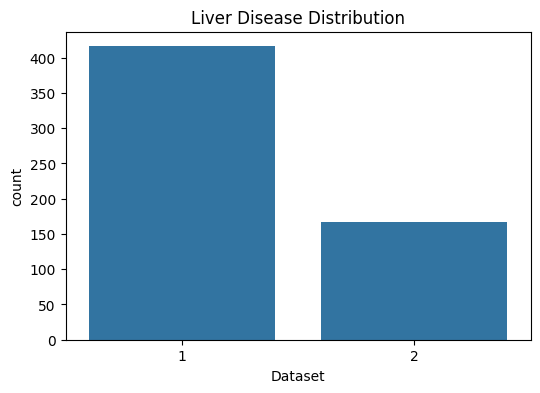

In [29]:
# Target Distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df_clean, x="Dataset")

plt.title("Liver Disease Distribution")

plt.show()

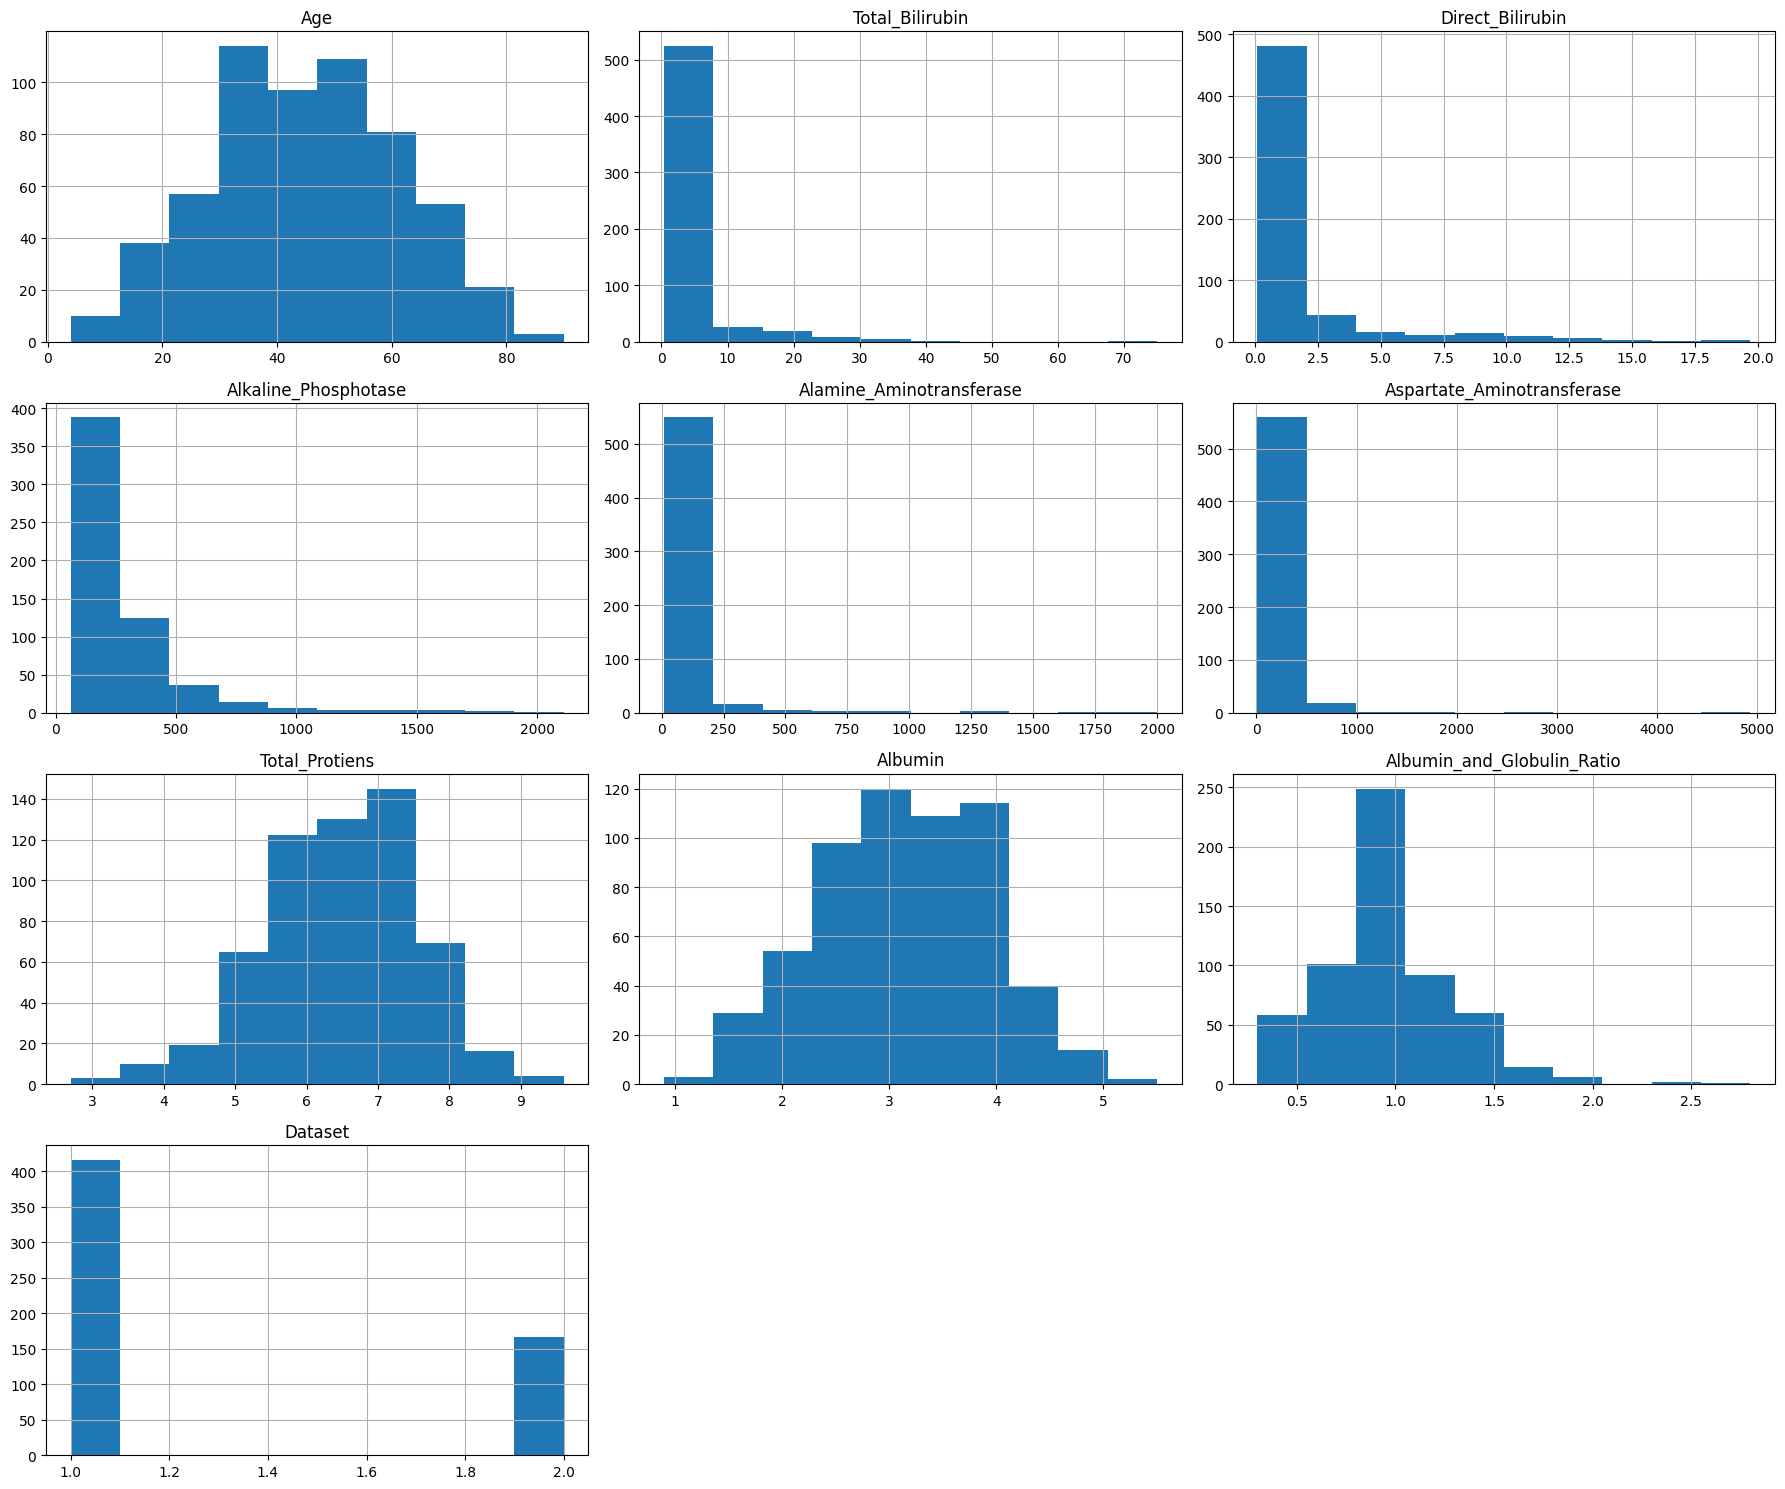

In [31]:
#Histograms
df_clean.hist(figsize=(18,15))

plt.tight_layout()

plt.show()

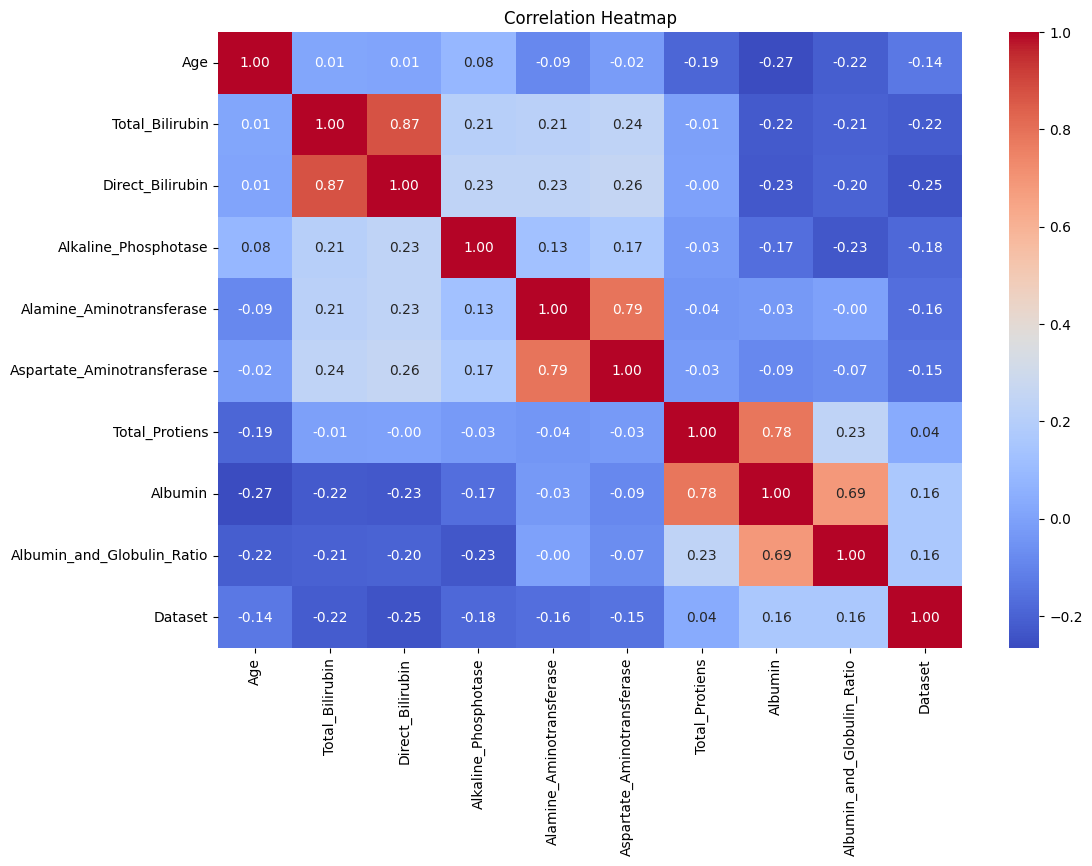

In [32]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

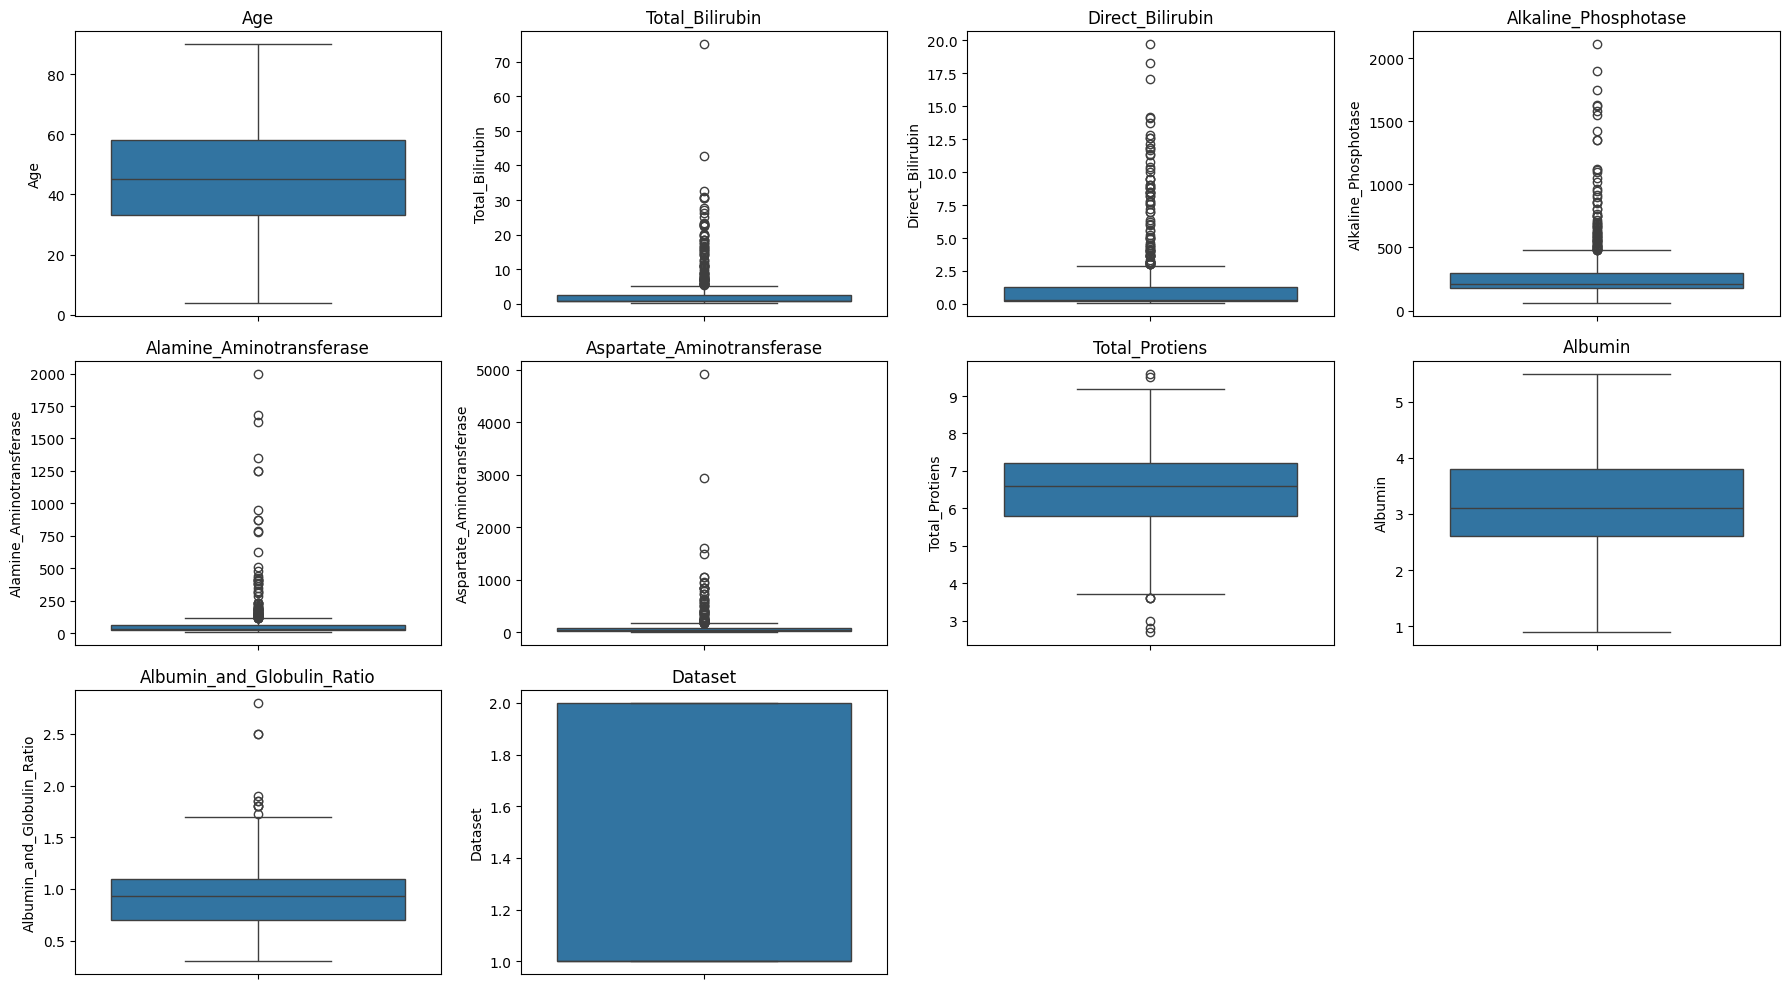

In [33]:
# Boxplots
numerical_columns = df_clean.select_dtypes(include="number").columns

plt.figure(figsize=(18,10))

for i, col in enumerate(numerical_columns):
    plt.subplot(3,4,i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(col)

plt.tight_layout()

plt.show()

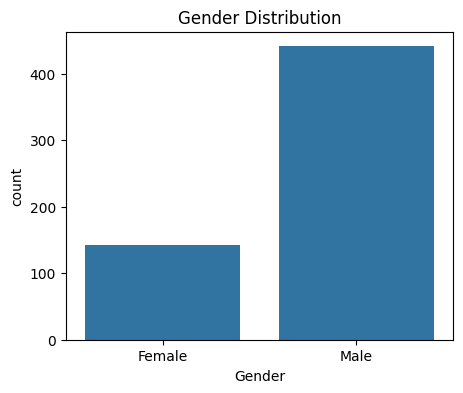

In [34]:
# Gender Distribution
plt.figure(figsize=(5,4))

sns.countplot(data=df_clean, x="Gender")

plt.title("Gender Distribution")

plt.show()

In [35]:
# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_model = df_clean.copy()

for col in cat_cols:
    df_model[col] = encoder.fit_transform(df_model[col])

In [28]:
# Split Features and Target
X = df_model.drop("Dataset", axis=1)

y = df_model["Dataset"]

In [37]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Step 3 – Model Training

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [40]:
# Create Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

In [41]:
# Train & Evaluate
results = []

for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [42]:
# Compare Models
results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.692308,0.641097,0.692308,0.644748
3,SVM,0.683761,0.497826,0.683761,0.576164
1,Decision Tree,0.606838,0.620242,0.606838,0.612905
2,Random Forest,0.589744,0.548732,0.589744,0.566032


In [43]:
# Train the Best Model
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

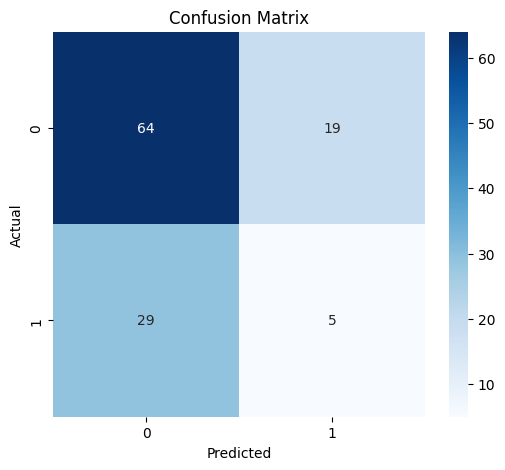

In [44]:
# Confusion Matrix
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
# Classification Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.69      0.77      0.73        83
           2       0.21      0.15      0.17        34

    accuracy                           0.59       117
   macro avg       0.45      0.46      0.45       117
weighted avg       0.55      0.59      0.57       117



### Step 4 – Feature Importance (If Random Forest)

In [46]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Alkaline_Phosphotase,0.152643
5,Alamine_Aminotransferase,0.133928
0,Age,0.131611
6,Aspartate_Aminotransferase,0.120456
8,Albumin,0.096847
2,Total_Bilirubin,0.092301
7,Total_Protiens,0.091947
3,Direct_Bilirubin,0.085495
9,Albumin_and_Globulin_Ratio,0.079317
1,Gender,0.015454


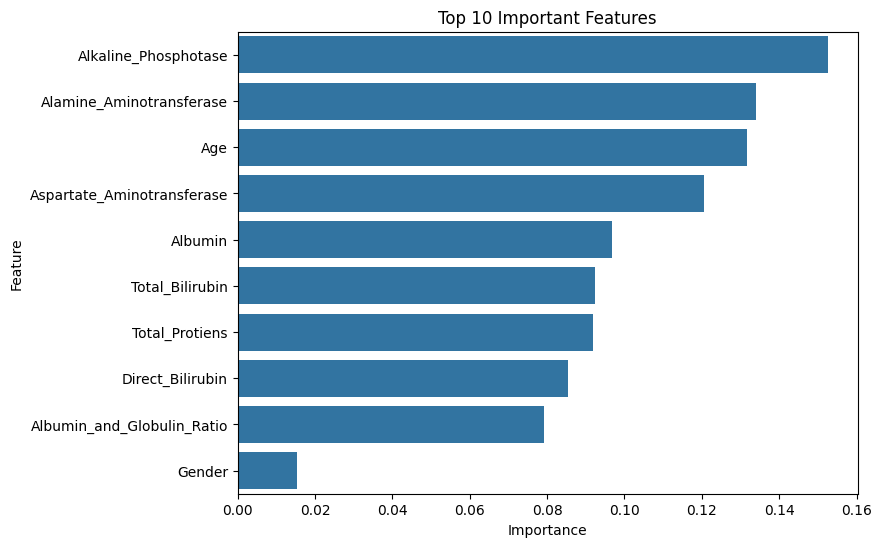

In [49]:
# Visualize Top 10 Features
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [52]:
# Save the Model
import joblib

joblib.dump(best_model, "liver_model.pkl")
joblib.dump(scaler, "liver_scaler.pkl")

['liver_scaler.pkl']

In [53]:
import os

os.listdir()

['.config',
 'liver_model.pkl',
 'indian_liver_patient.csv',
 'liver_scaler.pkl',
 'sample_data']